# SW and SE nearest-neighbour GAM analysis using raw DGR values

## Setup

In [ ]:
options(scipen = 999)

required_packages <- c(
  "sf",
  "dplyr",
  "tidyr",
  "purrr",
  "ggplot2",
  "patchwork",
  "readxl",
  "stringr",
  "mgcv"
)

missing_packages <- required_packages[!vapply(
  required_packages,
  requireNamespace,
  quietly = TRUE,
  FUN.VALUE = logical(1)
)]

if (length(missing_packages) > 0) {
  stop(
    paste(
      "Missing required package(s):",
      paste(missing_packages, collapse = ", "),
      "\nInstall them before rendering this Quarto document."
    ),
    call. = FALSE
  )
}

library(sf)


Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE


Attachement du package : 'dplyr'

Les objets suivants sont masqués depuis 'package:stats':

    filter, lag

Les objets suivants sont masqués depuis 'package:base':

    intersect, setdiff, setequal, union

Le chargement a nécessité le package : nlme


Attachement du package : 'nlme'

L'objet suivant est masqué depuis 'package:dplyr':

    collapse

This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.

## User Parameters

In [ ]:
cadaster_path <- "Data/shp/Cadaster_NBS_Dec2025.shp"
id_col <- "ID"

output_dir <- "Figures/Spatial_analysis"
presence_thresholds <- seq(10, 500, by = 10)
min_presence_group_n <- 10

harvest_path <- "Data/NBS - Récolte 2025.xlsx"
harvest_sheet <- "Copie base donnée"
min_culture_days <- 28
required_lines <- 100

save_dpi <- 300
plot_width <- 8.5
plot_height <- 6.0


## Helper Functions

In [ ]:
save_plot <- function(plot_obj, filename, width = plot_width, height = plot_height) {
  ggplot2::ggsave(
    filename = filename,
    plot = plot_obj,
    width = width,
    height = height,
    units = "in",
    dpi = save_dpi,
    bg = "white"
  )
}

theme_spatial <- function() {
  theme_minimal(base_size = 11) +
    theme(
      panel.grid.major = element_line(colour = "grey88", linewidth = 0.25),
      panel.grid.minor = element_blank(),
      strip.text = element_text(face = "bold"),
      axis.title = element_text(face = "bold"),
      legend.title = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(size = 10),
      plot.caption = element_text(size = 8, colour = "grey35")
    )
}

guess_utm_epsg <- function(sf_obj) {
  centroid_wgs84 <- st_as_sfc(st_bbox(sf_obj)) |>
    st_transform(4326) |>
    st_centroid()

  centroid_xy <- st_coordinates(centroid_wgs84)
  lon <- centroid_xy[1, "X"]
  lat <- centroid_xy[1, "Y"]
  zone <- floor((lon + 180) / 6) + 1
  if (lat >= 0) 32600 + zone else 32700 + zone
}

prepare_plot_geometry <- function(cadaster_path, id_col) {
  cadaster_sf <- st_read(cadaster_path, quiet = TRUE) |>
    st_make_valid()

  if (!id_col %in% names(cadaster_sf)) {
    stop(
      paste("The plot identifier column was not found in the shapefile:", id_col),
      call. = FALSE
    )
  }

  original_crs <- st_crs(cadaster_sf)
  if (is.na(original_crs)) {
    stop("The input shapefile has no CRS defined.", call. = FALSE)
  }

  original_crs_label <- original_crs$input
  transformed_crs_label <- original_crs_label

  if (isTRUE(st_is_longlat(cadaster_sf))) {
    utm_epsg <- guess_utm_epsg(cadaster_sf)
    cadaster_sf <- st_transform(cadaster_sf, utm_epsg)
    transformed_crs_label <- paste0("EPSG:", utm_epsg)
  }

  centroid_points <- st_point_on_surface(cadaster_sf)
  centroid_coords <- st_coordinates(centroid_points)

  cadaster_sf |>
    transmute(
      plot_id = as.character(.data[[id_col]]),
      x = centroid_coords[, "X"],
      y = centroid_coords[, "Y"]
    ) |>
    list(
      data = _,
      metadata = list(
        original_crs = original_crs_label,
        analysis_crs = transformed_crs_label
      )
    )
}

prepare_raw_dgr <- function(
  harvest_path,
  harvest_sheet,
  min_culture_days,
  required_lines
) {
  readxl::read_excel(harvest_path, sheet = harvest_sheet) |>
    mutate(
      FarmID = as.numeric(FarmID),
      ModuleNumber = as.numeric(ModuleNumber),
      Harvested_Weight = as.numeric(Harvested_Weight),
      CultureDuration_days = as.numeric(CultureDuration_days),
      LinesCount = as.numeric(LinesCount)
    ) |>
    filter(
      CultureMode == "Cordes",
      !is.na(FarmID),
      !is.na(ModuleNumber),
      !is.na(Harvested_Weight),
      !is.na(CultureDuration_days),
      CultureDuration_days >= min_culture_days,
      !is.na(LinesCount),
      LinesCount == required_lines,
      Harvested_Weight > 1000
    ) |>
    mutate(
      FarmID = stringr::str_pad(as.integer(FarmID), width = 3, pad = "0"),
      ModuleNumber = as.integer(ModuleNumber),
      Module_ID = paste0(FarmID, "_", ModuleNumber),
      DGR = (log(Harvested_Weight / 700) / CultureDuration_days) * 100
    ) |>
    select(Module_ID, FarmID, DGR)
}

build_sw_se_pairs <- function(plot_sf) {
  plot_tbl <- plot_sf |>
    st_drop_geometry() |>
    select(plot_id, x, y)

  tidyr::expand_grid(
    focal_index = seq_len(nrow(plot_tbl)),
    neighbour_index = seq_len(nrow(plot_tbl))
  ) |>
    filter(focal_index != neighbour_index) |>
    transmute(
      plot_id = plot_tbl$plot_id[focal_index],
      dx = plot_tbl$x[neighbour_index] - plot_tbl$x[focal_index],
      dy = plot_tbl$y[neighbour_index] - plot_tbl$y[focal_index]
    ) |>
    mutate(
      distance_m = sqrt(dx^2 + dy^2),
      direction = case_when(
        dx < 0 & dy < 0 ~ "SW",
        dx > 0 & dy < 0 ~ "SE",
        TRUE ~ NA_character_
      )
    ) |>
    filter(!is.na(direction), distance_m > 0)
}

compute_first_valid_threshold <- function(pair_tbl, raw_joined, thresholds, min_group_n) {
  threshold_counts <- purrr::map_dfr(thresholds, function(threshold_m) {
    threshold_summary <- pair_tbl |>
      filter(distance_m <= threshold_m) |>
      group_by(plot_id, direction) |>
      summarise(
        present = as.integer(dplyr::n() > 0),
        .groups = "drop"
      ) |>
      pivot_wider(
        names_from = direction,
        values_from = present,
        values_fill = 0,
        names_prefix = "present_"
      )

    for (nm in c("present_SW", "present_SE")) {
      if (!nm %in% names(threshold_summary)) {
        threshold_summary[[nm]] <- 0L
      }
    }

    dat <- raw_joined |>
      left_join(
        threshold_summary |>
          select(plot_id, present_SW, present_SE),
        by = "plot_id"
      ) |>
      mutate(
        present_SW = ifelse(is.na(present_SW), 0L, present_SW),
        present_SE = ifelse(is.na(present_SE), 0L, present_SE)
      )

    tibble(
      distance_threshold_m = threshold_m,
      sw0 = sum(dat$present_SW == 0),
      sw1 = sum(dat$present_SW == 1),
      se0 = sum(dat$present_SE == 0),
      se1 = sum(dat$present_SE == 1)
    )
  })

  threshold_counts |>
    filter(pmin(sw0, sw1, se0, se1) >= min_group_n) |>
    arrange(distance_threshold_m) |>
    slice(1)
}

compute_presence_combo_data <- function(pair_tbl, raw_joined, threshold_m) {
  threshold_summary <- pair_tbl |>
    filter(distance_m <= threshold_m) |>
    group_by(plot_id, direction) |>
    summarise(
      present = as.integer(dplyr::n() > 0),
      .groups = "drop"
    ) |>
    pivot_wider(
      names_from = direction,
      values_from = present,
      values_fill = 0,
      names_prefix = "present_"
    )

  for (nm in c("present_SW", "present_SE")) {
    if (!nm %in% names(threshold_summary)) {
      threshold_summary[[nm]] <- 0L
    }
  }

  raw_joined |>
    left_join(
      threshold_summary |>
        select(plot_id, present_SW, present_SE),
      by = "plot_id"
    ) |>
    mutate(
      present_SW = ifelse(is.na(present_SW), 0L, present_SW),
      present_SE = ifelse(is.na(present_SE), 0L, present_SE),
      combo = case_when(
        present_SW == 0 & present_SE == 0 ~ "Neither",
        present_SW == 1 & present_SE == 0 ~ "SW only",
        present_SW == 0 & present_SE == 1 ~ "SE only",
        TRUE ~ "SW + SE"
      ),
      combo = factor(combo, levels = c("Neither", "SW only", "SE only", "SW + SE"))
    )
}

compute_closest_distances <- function(pair_tbl) {
  pair_tbl |>
    group_by(plot_id, direction) |>
    summarise(
      closest_distance_m = min(distance_m, na.rm = TRUE),
      .groups = "drop"
    ) |>
    pivot_wider(
      names_from = direction,
      values_from = closest_distance_m,
      names_prefix = "closest_"
    )
}

extract_parametric_table <- function(model_fit) {
  ptab <- summary(model_fit)$p.table
  tibble(
    term = rownames(ptab),
    estimate = ptab[, "Estimate"],
    std.error = ptab[, "Std. Error"],
    statistic = ptab[, "t value"],
    p.value = ptab[, "Pr(>|t|)"],
    conf.low = estimate - 1.96 * std.error,
    conf.high = estimate + 1.96 * std.error
  )
}

extract_smooth_table <- function(model_fit) {
  stab <- summary(model_fit)$s.table
  tibble(
    term = rownames(stab),
    edf = stab[, "edf"],
    ref.df = stab[, "Ref.df"],
    f_stat = stab[, "F"],
    p.value = stab[, "p-value"]
  )
}

write_interpretation <- function(
  output_file,
  first_valid_threshold,
  combo_summary,
  se_model_summary,
  swse_model_summary,
  se_smooth_tbl,
  swse_smooth_tbl,
  n_rows,
  n_modules
) {
  combo_means <- combo_summary$mean_DGR
  names(combo_means) <- combo_summary$combo

  interpretation_lines <- c(
    "# Spatial analysis interpretation",
    "",
    "## Data used",
    paste(
      "This analysis uses raw DGR values, restricted to harvests with exactly",
      sprintf("`%d` lines", required_lines),
      "and at least",
      sprintf("`%d` days", min_culture_days),
      "of cultivation."
    ),
    sprintf(
      "The final joined dataset contains %d raw DGR observations from %d modules.",
      n_rows,
      n_modules
    ),
    "",
    "## Presence plot retained",
    sprintf(
      paste(
        "At %d m, the combination plot still shows the same broad pattern:",
        "the highest mean raw DGR occurs when neither SW nor SE neighbours are present (%.2f),",
        "intermediate mean DGR occurs for `SW only` (%.2f) and `SE only` (%.2f),",
        "and the lowest mean raw DGR occurs when both SW and SE neighbours are present (%.2f)."
      ),
      first_valid_threshold,
      combo_means["Neither"],
      combo_means["SW only"],
      combo_means["SE only"],
      combo_means["SW + SE"]
    ),
    "",
    "## GAM models fitted",
    paste(
      "Two GAMs were fitted with module-level random effects to account for repeated",
      "raw measurements within the same module."
    ),
    paste(
      "Model 1 tests the SE effect alone:",
      "`DGR ~ s(log(SE_distance)) + random module effect`."
    ),
    sprintf(
      "For Model 1, the smooth SE term had p = %.3g, adjusted R2 = %.3f, deviance explained = %.1f%%, and AIC = %.1f.",
      se_smooth_tbl$p.value[se_smooth_tbl$term == "s(log_closest_SE)"],
      se_model_summary$adj_r_squared[1],
      100 * se_model_summary$deviance_explained[1],
      se_model_summary$AIC[1]
    ),
    paste(
      "Model 2 is the final joint model:",
      "`DGR ~ s(log(SW_distance)) + s(log(SE_distance)) + random module effect`."
    ),
    sprintf(
      "For Model 2, the SW smooth had p = %.3g and the SE smooth had p = %.3g; adjusted R2 = %.3f, deviance explained = %.1f%%, and AIC = %.1f.",
      swse_smooth_tbl$p.value[swse_smooth_tbl$term == "s(log_closest_SW)"],
      swse_smooth_tbl$p.value[swse_smooth_tbl$term == "s(log_closest_SE)"],
      swse_model_summary$adj_r_squared[1],
      100 * swse_model_summary$deviance_explained[1],
      swse_model_summary$AIC[1]
    ),
    "",
    "## Practical interpretation",
    paste(
      "The SE-only GAM confirms that SE neighbour distance has a detectable relationship",
      "with raw DGR even after accounting for repeated measurements within module."
    ),
    paste(
      "The final SW+SE GAM shows that the best predictive model uses both directional",
      "distances together, even if SW was weak when examined on its own earlier."
    ),
    paste(
      "Because this is a GAM, there is no single straight-line equation to summarize",
      "the effect. Instead, the estimated DGR for each module should be taken from the",
      "prediction table generated from the final SW+SE model."
    ),
    "",
    "## Output for module-level estimated DGR",
    paste(
      "Estimated DGR for each module, based only on its SW and SE nearest-neighbour",
      "distances, is saved in",
      "[module_distance_based_dgr_estimates.csv](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/module_distance_based_dgr_estimates.csv:1>)."
    ),
    "",
    "## Plot support",
    paste(
      "- Presence-combination plot:",
      "[sw_se_presence_combinations_first_valid_threshold.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/sw_se_presence_combinations_first_valid_threshold.png:1>)"
    ),
    paste(
      "- SE-only GAM effect:",
      "[se_only_gam_effect.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/se_only_gam_effect.png:1>)"
    ),
    paste(
      "- Final SW+SE GAM effects:",
      "[sw_se_gam_effects.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/sw_se_gam_effects.png:1>)"
    ),
    paste(
      "- Final SW+SE predicted DGR surface:",
      "[sw_se_gam_predicted_dgr_surface.png](</C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis/sw_se_gam_predicted_dgr_surface.png:1>)"
    ),
    "",
    "## Caution",
    paste(
      "These are exploratory spatial models. Distance terms may reflect neighbour effects,",
      "but they may also be proxies for unmeasured environmental gradients."
    )
  )

  writeLines(interpretation_lines, con = output_file)
}


## Load Geometry And Raw DGR

In [ ]:
dir.create(output_dir, showWarnings = FALSE, recursive = TRUE)

plot_prep <- prepare_plot_geometry(
  cadaster_path = cadaster_path,
  id_col = id_col
)


Original CRS: WGS 84 / UTM zone 39S 

Analysis CRS: WGS 84 / UTM zone 39S 

Raw rows after filtering and spatial join: 4577 

Modules represented: 683 

## SW/SE Pair Table

In [ ]:
pair_tbl <- build_sw_se_pairs(plot_sf)
closest_distance_tbl <- compute_closest_distances(pair_tbl) |>
  rename(
    closest_SW_distance_m = closest_SW,
    closest_SE_distance_m = closest_SE
  )


## Keep The Presence-Combination Plot

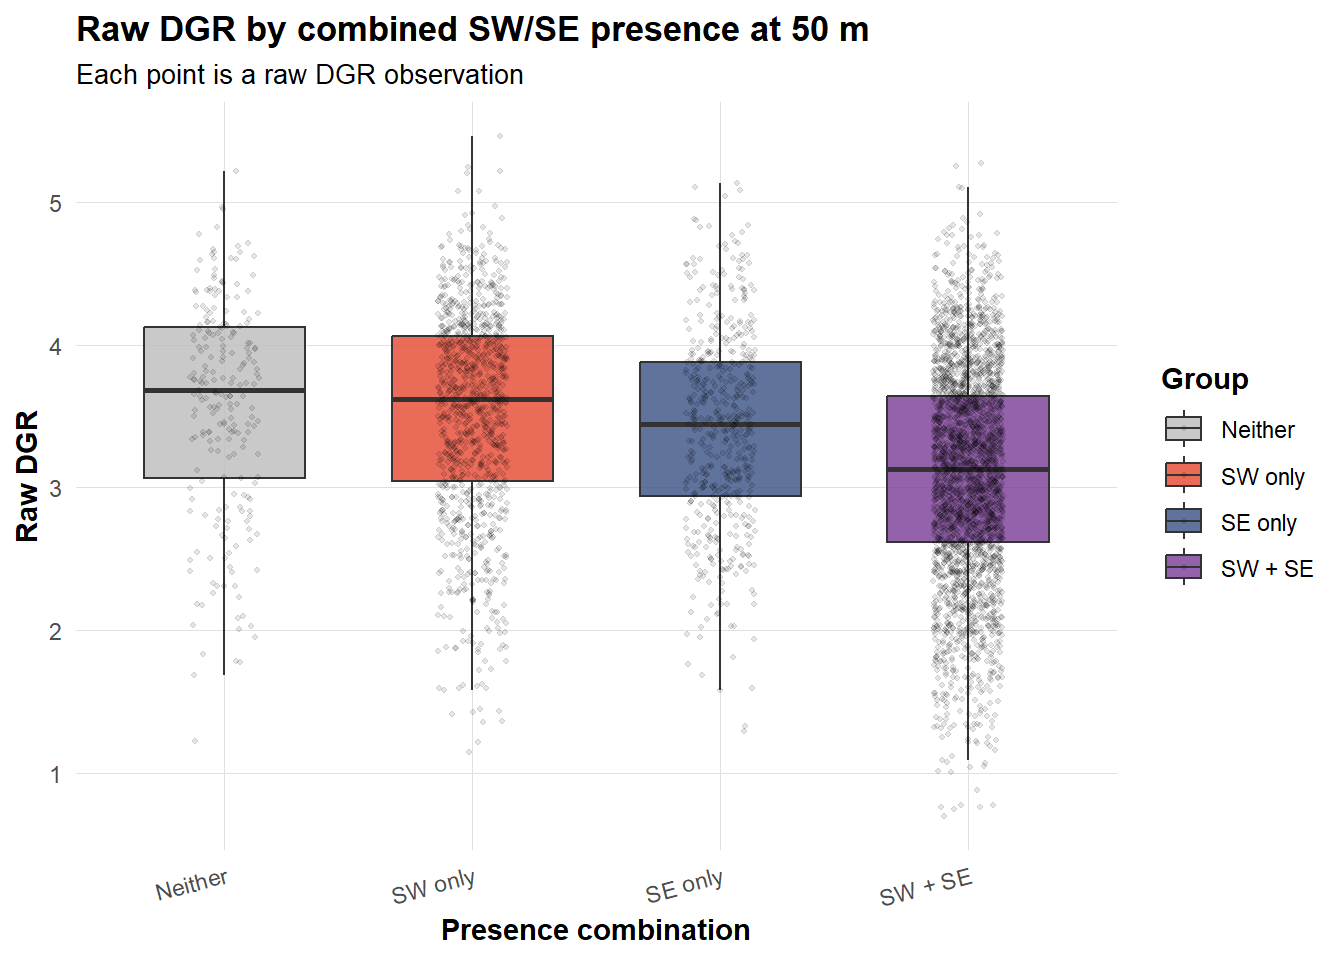

In [ ]:
first_valid_threshold_row <- compute_first_valid_threshold(
  pair_tbl = pair_tbl,
  raw_joined = raw_joined,
  thresholds = presence_thresholds,
  min_group_n = min_presence_group_n
)

first_valid_threshold <- first_valid_threshold_row$distance_threshold_m[1]

combo_data <- compute_presence_combo_data(
  pair_tbl = pair_tbl,
  raw_joined = raw_joined,
  threshold_m = first_valid_threshold
)

combo_summary <- combo_data |>
  group_by(combo) |>
  summarise(
    n = dplyr::n(),
    mean_DGR = mean(DGR, na.rm = TRUE),
    .groups = "drop"
  )

combo_plot <- ggplot(
  combo_data,
  aes(x = combo, y = DGR, fill = combo)
) +
  geom_boxplot(alpha = 0.82, outlier.shape = NA, width = 0.65) +
  geom_jitter(
    width = 0.14,
    alpha = 0.10,
    size = 0.7,
    colour = "black"
  ) +
  scale_fill_manual(
    values = c(
      "Neither" = "#BDBDBD",
      "SW only" = "#E64B35",
      "SE only" = "#3C5488",
      "SW + SE" = "#7B3F98"
    ),
    drop = FALSE
  ) +
  labs(
    title = paste0("Raw DGR by combined SW/SE presence at ", first_valid_threshold, " m"),
    subtitle = "Each point is a raw DGR observation",
    x = "Presence combination",
    y = "Raw DGR",
    fill = "Group"
  ) +
  theme_spatial() +
  theme(axis.text.x = element_text(angle = 15, hjust = 1))

save_plot(
  combo_plot,
  file.path(output_dir, "sw_se_presence_combinations_first_valid_threshold.png"),
  width = 9.5,
  height = 6.5
)

combo_plot


## Final Modelling Dataset

In [ ]:
raw_model_data <- raw_joined |>
  left_join(closest_distance_tbl, by = "plot_id") |>
  filter(
    !is.na(closest_SW_distance_m),
    !is.na(closest_SE_distance_m)
  ) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m),
    plot_id = as.factor(plot_id)
  )

utils::write.csv(
  raw_model_data |>
    select(plot_id, DGR, closest_SW_distance_m, closest_SE_distance_m, log_closest_SW, log_closest_SE),
  file.path(output_dir, "closest_sw_se_distance_data.csv"),
  row.names = FALSE
)


## GAM 1: DGR ~ SE

In [ ]:
se_only_gam <- mgcv::bam(
  DGR ~ s(log_closest_SE, k = 6) + s(plot_id, bs = "re"),
  data = raw_model_data,
  method = "fREML",
  discrete = TRUE
)

se_only_smooth_tbl <- extract_smooth_table(se_only_gam)
se_only_summary_tbl <- tibble(
  n_rows = nrow(raw_model_data),
  n_modules = dplyr::n_distinct(raw_model_data$plot_id),
  adj_r_squared = summary(se_only_gam)$r.sq,
  deviance_explained = summary(se_only_gam)$dev.expl,
  AIC = AIC(se_only_gam)
)

utils::write.csv(
  se_only_smooth_tbl,
  file.path(output_dir, "se_only_gam_smooth_terms.csv"),
  row.names = FALSE
)

utils::write.csv(
  se_only_summary_tbl,
  file.path(output_dir, "se_only_gam_summary.csv"),
  row.names = FALSE
)


## GAM 2: DGR ~ SW + SE

In [ ]:
sw_se_gam <- mgcv::bam(
  DGR ~ s(log_closest_SW, k = 6) + s(log_closest_SE, k = 6) + s(plot_id, bs = "re"),
  data = raw_model_data,
  method = "fREML",
  discrete = TRUE
)

sw_se_smooth_tbl <- extract_smooth_table(sw_se_gam)
sw_se_summary_tbl <- tibble(
  n_rows = nrow(raw_model_data),
  n_modules = dplyr::n_distinct(raw_model_data$plot_id),
  adj_r_squared = summary(sw_se_gam)$r.sq,
  deviance_explained = summary(sw_se_gam)$dev.expl,
  AIC = AIC(sw_se_gam)
)

utils::write.csv(
  sw_se_smooth_tbl,
  file.path(output_dir, "sw_se_gam_smooth_terms.csv"),
  row.names = FALSE
)

utils::write.csv(
  sw_se_summary_tbl,
  file.path(output_dir, "sw_se_gam_summary.csv"),
  row.names = FALSE
)


## Module-Level Estimated DGR

In [ ]:
module_prediction_data <- raw_model_data |>
  distinct(plot_id, closest_SW_distance_m, closest_SE_distance_m, log_closest_SW, log_closest_SE)

se_only_pred <- predict(
  se_only_gam,
  newdata = module_prediction_data,
  exclude = "s(plot_id)",
  se.fit = TRUE
)

sw_se_pred <- predict(
  sw_se_gam,
  newdata = module_prediction_data,
  exclude = "s(plot_id)",
  se.fit = TRUE
)

module_distance_based_estimates <- module_prediction_data |>
  mutate(
    predicted_DGR_se_only = as.numeric(se_only_pred$fit),
    predicted_DGR_se_only_lwr = predicted_DGR_se_only - 1.96 * as.numeric(se_only_pred$se.fit),
    predicted_DGR_se_only_upr = predicted_DGR_se_only + 1.96 * as.numeric(se_only_pred$se.fit),
    predicted_DGR_sw_se = as.numeric(sw_se_pred$fit),
    predicted_DGR_sw_se_lwr = predicted_DGR_sw_se - 1.96 * as.numeric(sw_se_pred$se.fit),
    predicted_DGR_sw_se_upr = predicted_DGR_sw_se + 1.96 * as.numeric(sw_se_pred$se.fit)
  ) |>
  arrange(plot_id)

utils::write.csv(
  module_distance_based_estimates,
  file.path(output_dir, "module_distance_based_dgr_estimates.csv"),
  row.names = FALSE
)


## Plot Support

In [ ]:
median_sw <- median(raw_model_data$closest_SW_distance_m, na.rm = TRUE)
median_se <- median(raw_model_data$closest_SE_distance_m, na.rm = TRUE)
reference_plot_id <- module_distance_based_estimates$plot_id[1]

se_grid <- data.frame(
  plot_id = factor(reference_plot_id, levels = levels(raw_model_data$plot_id)),
  closest_SW_distance_m = median_sw,
  closest_SE_distance_m = exp(seq(
    log(min(raw_model_data$closest_SE_distance_m)),
    log(max(raw_model_data$closest_SE_distance_m)),
    length.out = 200
  ))
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  )

se_grid_pred <- predict(
  se_only_gam,
  newdata = se_grid,
  exclude = "s(plot_id)",
  se.fit = TRUE
)

se_grid <- se_grid |>
  mutate(
    fit = as.numeric(se_grid_pred$fit),
    lwr = fit - 1.96 * as.numeric(se_grid_pred$se.fit),
    upr = fit + 1.96 * as.numeric(se_grid_pred$se.fit)
  )

se_only_effect_plot <- ggplot() +
  geom_point(
    data = raw_model_data,
    aes(x = closest_SE_distance_m, y = DGR),
    alpha = 0.08,
    size = 0.6,
    colour = "#3C5488"
  ) +
  geom_ribbon(
    data = se_grid,
    aes(x = closest_SE_distance_m, ymin = lwr, ymax = upr),
    alpha = 0.20,
    fill = "#3C5488"
  ) +
  geom_line(
    data = se_grid,
    aes(x = closest_SE_distance_m, y = fit),
    linewidth = 1.0,
    colour = "#3C5488"
  ) +
  scale_x_log10() +
  labs(
    title = "SE-only GAM effect",
    subtitle = "Population-level prediction from DGR ~ s(log(SE)) + random module effect",
    x = "Closest SE neighbour distance (m, log scale)",
    y = "Predicted raw DGR"
  ) +
  theme_spatial()

save_plot(
  se_only_effect_plot,
  file.path(output_dir, "se_only_gam_effect.png"),
  width = 8.8,
  height = 6.0
)

sw_grid <- data.frame(
  plot_id = factor(reference_plot_id, levels = levels(raw_model_data$plot_id)),
  closest_SW_distance_m = exp(seq(
    log(min(raw_model_data$closest_SW_distance_m)),
    log(max(raw_model_data$closest_SW_distance_m)),
    length.out = 200
  )),
  closest_SE_distance_m = median_se
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  )

sw_grid_pred <- predict(
  sw_se_gam,
  newdata = sw_grid,
  exclude = "s(plot_id)",
  se.fit = TRUE
)

sw_grid <- sw_grid |>
  mutate(
    fit = as.numeric(sw_grid_pred$fit),
    lwr = fit - 1.96 * as.numeric(sw_grid_pred$se.fit),
    upr = fit + 1.96 * as.numeric(sw_grid_pred$se.fit),
    direction = "SW",
    distance_m = closest_SW_distance_m
  )

se_joint_grid <- data.frame(
  plot_id = factor(reference_plot_id, levels = levels(raw_model_data$plot_id)),
  closest_SW_distance_m = median_sw,
  closest_SE_distance_m = exp(seq(
    log(min(raw_model_data$closest_SE_distance_m)),
    log(max(raw_model_data$closest_SE_distance_m)),
    length.out = 200
  ))
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  )

se_joint_pred <- predict(
  sw_se_gam,
  newdata = se_joint_grid,
  exclude = "s(plot_id)",
  se.fit = TRUE
)

se_joint_grid <- se_joint_grid |>
  mutate(
    fit = as.numeric(se_joint_pred$fit),
    lwr = fit - 1.96 * as.numeric(se_joint_pred$se.fit),
    upr = fit + 1.96 * as.numeric(se_joint_pred$se.fit),
    direction = "SE",
    distance_m = closest_SE_distance_m
  )

joint_effect_grid <- bind_rows(sw_grid, se_joint_grid)

joint_effect_points <- bind_rows(
  raw_model_data |>
    transmute(direction = "SW", distance_m = closest_SW_distance_m, DGR = DGR),
  raw_model_data |>
    transmute(direction = "SE", distance_m = closest_SE_distance_m, DGR = DGR)
)

sw_se_effect_plot <- ggplot() +
  geom_point(
    data = joint_effect_points,
    aes(x = distance_m, y = DGR, colour = direction),
    alpha = 0.08,
    size = 0.6
  ) +
  geom_ribbon(
    data = joint_effect_grid,
    aes(x = distance_m, ymin = lwr, ymax = upr, fill = direction),
    alpha = 0.20,
    colour = NA
  ) +
  geom_line(
    data = joint_effect_grid,
    aes(x = distance_m, y = fit, colour = direction),
    linewidth = 1.0
  ) +
  facet_wrap(~ direction, scales = "free_x") +
  scale_x_log10() +
  scale_colour_manual(values = c(SW = "#E64B35", SE = "#3C5488"), drop = FALSE) +
  scale_fill_manual(values = c(SW = "#E64B35", SE = "#3C5488"), drop = FALSE) +
  labs(
    title = "Final SW+SE GAM effects",
    subtitle = "Population-level predictions from the joint model",
    x = "Closest-neighbour distance (m, log scale)",
    y = "Predicted raw DGR",
    colour = "Direction",
    fill = "Direction"
  ) +
  theme_spatial() +
  theme(legend.position = "none")

save_plot(
  sw_se_effect_plot,
  file.path(output_dir, "sw_se_gam_effects.png"),
  width = 10.5,
  height = 6.5
)

surface_grid <- expand_grid(
  plot_id = factor(reference_plot_id, levels = levels(raw_model_data$plot_id)),
  closest_SW_distance_m = exp(seq(
    log(min(raw_model_data$closest_SW_distance_m)),
    log(max(raw_model_data$closest_SW_distance_m)),
    length.out = 120
  )),
  closest_SE_distance_m = exp(seq(
    log(min(raw_model_data$closest_SE_distance_m)),
    log(max(raw_model_data$closest_SE_distance_m)),
    length.out = 120
  ))
) |>
  mutate(
    log_closest_SW = log(closest_SW_distance_m),
    log_closest_SE = log(closest_SE_distance_m)
  )

surface_pred <- predict(
  sw_se_gam,
  newdata = surface_grid,
  exclude = "s(plot_id)",
  se.fit = TRUE
)

surface_grid <- surface_grid |>
  mutate(
    fit = as.numeric(surface_pred$fit),
    lwr = fit - 1.96 * as.numeric(surface_pred$se.fit),
    upr = fit + 1.96 * as.numeric(surface_pred$se.fit)
  )

utils::write.csv(
  surface_grid |>
    select(closest_SW_distance_m, closest_SE_distance_m, fit, lwr, upr),
  file.path(output_dir, "sw_se_gam_prediction_grid.csv"),
  row.names = FALSE
)

surface_plot <- ggplot(
  surface_grid,
  aes(x = closest_SW_distance_m, y = closest_SE_distance_m, fill = fit)
) +
  geom_raster(interpolate = TRUE) +
  geom_contour(
    aes(z = fit),
    colour = "white",
    alpha = 0.65
  ) +
  geom_point(
    data = module_distance_based_estimates,
    aes(x = closest_SW_distance_m, y = closest_SE_distance_m),
    inherit.aes = FALSE,
    alpha = 0.22,
    size = 0.7,
    colour = "black"
  ) +
  scale_x_log10() +
  scale_y_log10() +
  scale_fill_viridis_c(option = "D", name = "Predicted raw DGR") +
  labs(
    title = "Predicted raw DGR from the final SW+SE GAM",
    subtitle = "Population-level surface for module-level distance combinations",
    x = "Closest SW neighbour distance (m, log scale)",
    y = "Closest SE neighbour distance (m, log scale)"
  ) +
  theme_spatial()

save_plot(
  surface_plot,
  file.path(output_dir, "sw_se_gam_predicted_dgr_surface.png"),
  width = 8.8,
  height = 7.2
)


ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?

ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?

## Update Interpretation File

In [ ]:
write_interpretation(
  output_file = file.path(output_dir, "spatial_analysis_interpretation.md"),
  first_valid_threshold = first_valid_threshold,
  combo_summary = combo_summary,
  se_model_summary = se_only_summary_tbl,
  swse_model_summary = sw_se_summary_tbl,
  se_smooth_tbl = se_only_smooth_tbl,
  swse_smooth_tbl = sw_se_smooth_tbl,
  n_rows = nrow(raw_model_data),
  n_modules = dplyr::n_distinct(raw_model_data$plot_id)
)


## Console Summary

In [ ]:
cat("\nRaw-value SW/SE GAM analysis complete.\n")



Raw-value SW/SE GAM analysis complete.

Outputs saved to: C:/Users/Simon/Nextcloud/Papers/First Authors/MadaKapPy_Paper_2026/Figures/Spatial_analysis 

Model 1 (SE only): adjusted R2 = 0.231, AIC = 7904.8. Model 2 (SW + SE): adjusted R2 = 0.231, AIC = 7895.5.